# House Price Prediction — Training Notebook

| Info | Detail |
|------|--------|
| **Author** | Aditya Ulil Albab |
| **NIM** | A11.2023.15093 |
| **Kampus** | Universitas Dian Nuswantoro |
| **Dataset** | House Prices: Advanced Regression Techniques (Kaggle) |

## ⚙️ Setup & Import Libraries

In [6]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 📁 Path Configuration

In [7]:
# Sesuaikan BASE_DIR dengan lokasi project Anda
BASE_DIR    = os.path.dirname(os.path.abspath("."))
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
MODELS_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATASET_DIR, "train.csv")

print(f"Base dir   : {BASE_DIR}")
print(f"Dataset dir: {DATASET_DIR}")
print(f"Models dir : {MODELS_DIR}")

Base dir   : /Users/mymac/anaconda_projects/portofolio
Dataset dir: /Users/mymac/anaconda_projects/portofolio/dataset
Models dir : /Users/mymac/anaconda_projects/portofolio/models


---
## 1️⃣ Load & Inspect Data

In [8]:
df = pd.read_csv(TRAIN_PATH)

print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target  — Mean: ${df['SalePrice'].mean():,.0f} | Std: ${df['SalePrice'].std():,.0f}")

df.head()

Shape   : 1,460 rows × 81 columns
Target  — Mean: $180,921 | Std: $79,443


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [9]:
# Basic info & missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Kolom dengan missing values:")
print(missing)

Kolom dengan missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [10]:
# Drop high-null columns & ID
DROP_COLS = ['PoolQC', 'MiscFeature', 'Alley', 'Fence',
             'MasVnrType', 'FireplaceQu', 'Id']
df.drop(columns=DROP_COLS, inplace=True, errors='ignore')

print(f"Shape setelah drop: {df.shape}")

Shape setelah drop: (1460, 74)


---
## 2️⃣ Feature Split

In [11]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

NUM_COLS = [
    'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
    'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
    'MoSold', 'YrSold'
]
CAT_COLS = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
    'SaleType', 'SaleCondition'
]

# Keep only columns that exist in df
NUM_COLS = [c for c in NUM_COLS if c in X.columns]
CAT_COLS = [c for c in CAT_COLS if c in X.columns]

print(f"🔢 Numerical features : {len(NUM_COLS)}")
print(f"📝 Categorical features: {len(CAT_COLS)}")

🔢 Numerical features : 36
📝 Categorical features: 37


---
## 3️⃣ Preprocessing Pipeline

In [12]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    )),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_COLS),
    ('cat', cat_pipe, CAT_COLS),
])

print("✅ Preprocessor berhasil dibuat")
print(f"   - Numerical  : median imputer + standard scaler")
print(f"   - Categorical: most_frequent imputer + ordinal encoder")

✅ Preprocessor berhasil dibuat
   - Numerical  : median imputer + standard scaler
   - Categorical: most_frequent imputer + ordinal encoder


---
## 4️⃣ Training & Evaluasi Model

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")

Training set  : 1,168 samples
Validation set: 292 samples


In [14]:
MODELS = {
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42
    ),
    "Ridge Regression": Ridge(alpha=10.0),
}

results   = {}
pipelines = {}

for name, estimator in MODELS.items():
    print(f"Training {name}...", end=" ")
    pipe = Pipeline([('pre', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)

    rmse = float(np.sqrt(mean_squared_error(y_val, preds)))
    mae  = float(mean_absolute_error(y_val, preds))
    r2   = float(r2_score(y_val, preds))

    results[name]   = {"rmse": round(rmse, 2), "mae": round(mae, 2), "r2": round(r2, 4)}
    pipelines[name] = pipe

    print(f"✅ RMSE: ${rmse:>10,.2f} | MAE: ${mae:>10,.2f} | R²: {r2:.4f}")

Training Gradient Boosting... ✅ RMSE: $ 27,254.21 | MAE: $ 16,359.43 | R²: 0.9032
Training Random Forest... ✅ RMSE: $ 28,499.09 | MAE: $ 17,496.53 | R²: 0.8941
Training Ridge Regression... ✅ RMSE: $ 34,366.35 | MAE: $ 21,392.11 | R²: 0.8460


In [15]:
# Ringkasan perbandingan model
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r2', ascending=False)
print("\n📊 Model Comparison:")
display(results_df)

best_model = pipelines["Gradient Boosting"]
best_preds = best_model.predict(X_val)
print(f"\n🏆 Best model: Gradient Boosting (R² = {results['Gradient Boosting']['r2']})")


📊 Model Comparison:


,rmse,mae,r2
Gradient Boosting,27254.21,16359.43,0.9032
Random Forest,28499.09,17496.53,0.8941
Ridge Regression,34366.35,21392.11,0.8460



🏆 Best model: Gradient Boosting (R² = 0.9032)


---
## 5️⃣ Visualisasi

### 5a. Model Performance

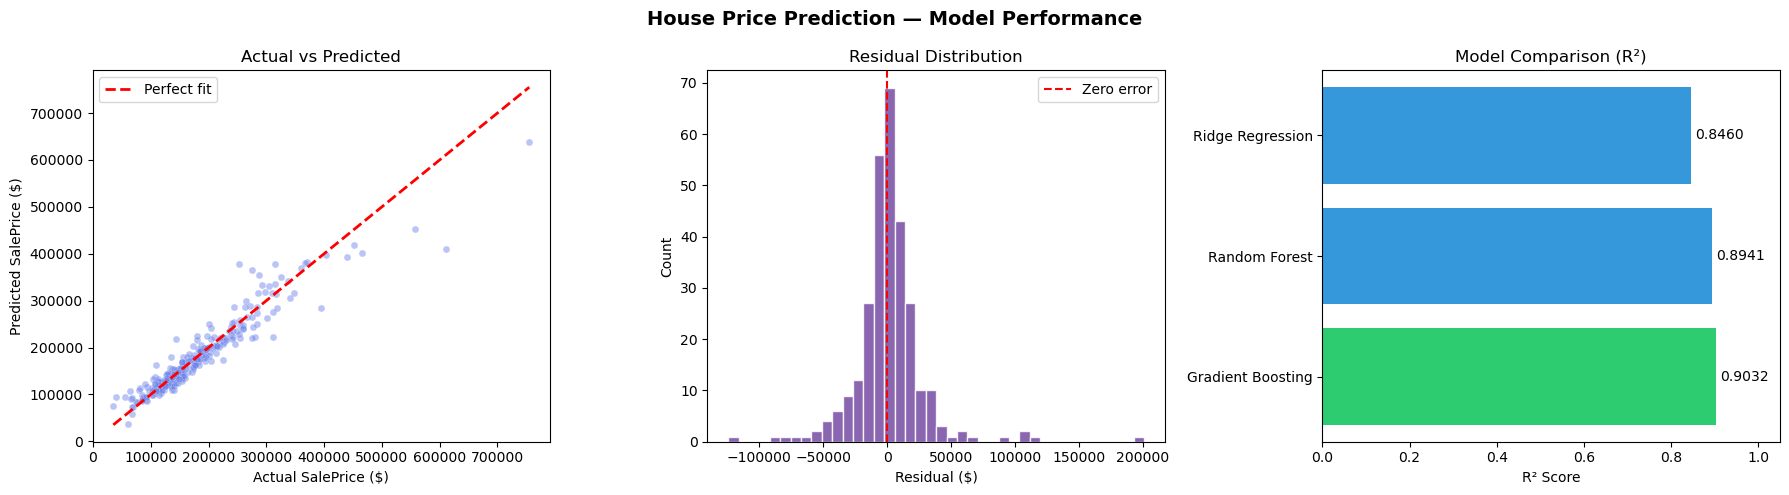

✅ Saved: /Users/mymac/anaconda_projects/portofolio/models/model_performance.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("House Price Prediction — Model Performance", fontsize=14, fontweight='bold')

residuals = y_val.values - best_preds

# Actual vs Predicted
axes[0].scatter(y_val, best_preds, alpha=0.45, color='#667eea',
                edgecolors='white', linewidth=0.3, s=25)
lim = [y_val.min(), y_val.max()]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel("Actual SalePrice ($)")
axes[0].set_ylabel("Predicted SalePrice ($)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Residual Distribution
axes[1].hist(residuals, bins=40, color='#764ba2', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].legend()

# R² Bar chart
names  = list(results.keys())
r2vals = [results[m]['r2'] for m in names]
colors = ['#2ecc71' if m == 'Gradient Boosting' else '#3498db' for m in names]
bars   = axes[2].barh(names, r2vals, color=colors)
axes[2].set_xlabel("R² Score")
axes[2].set_title("Model Comparison (R²)")
axes[2].set_xlim(0, 1.05)
for bar, val in zip(bars, r2vals):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va='center', fontsize=10)

plt.tight_layout()
perf_path = os.path.join(MODELS_DIR, "model_performance.png")
plt.savefig(perf_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {perf_path}")

### 5b. Feature Distribution

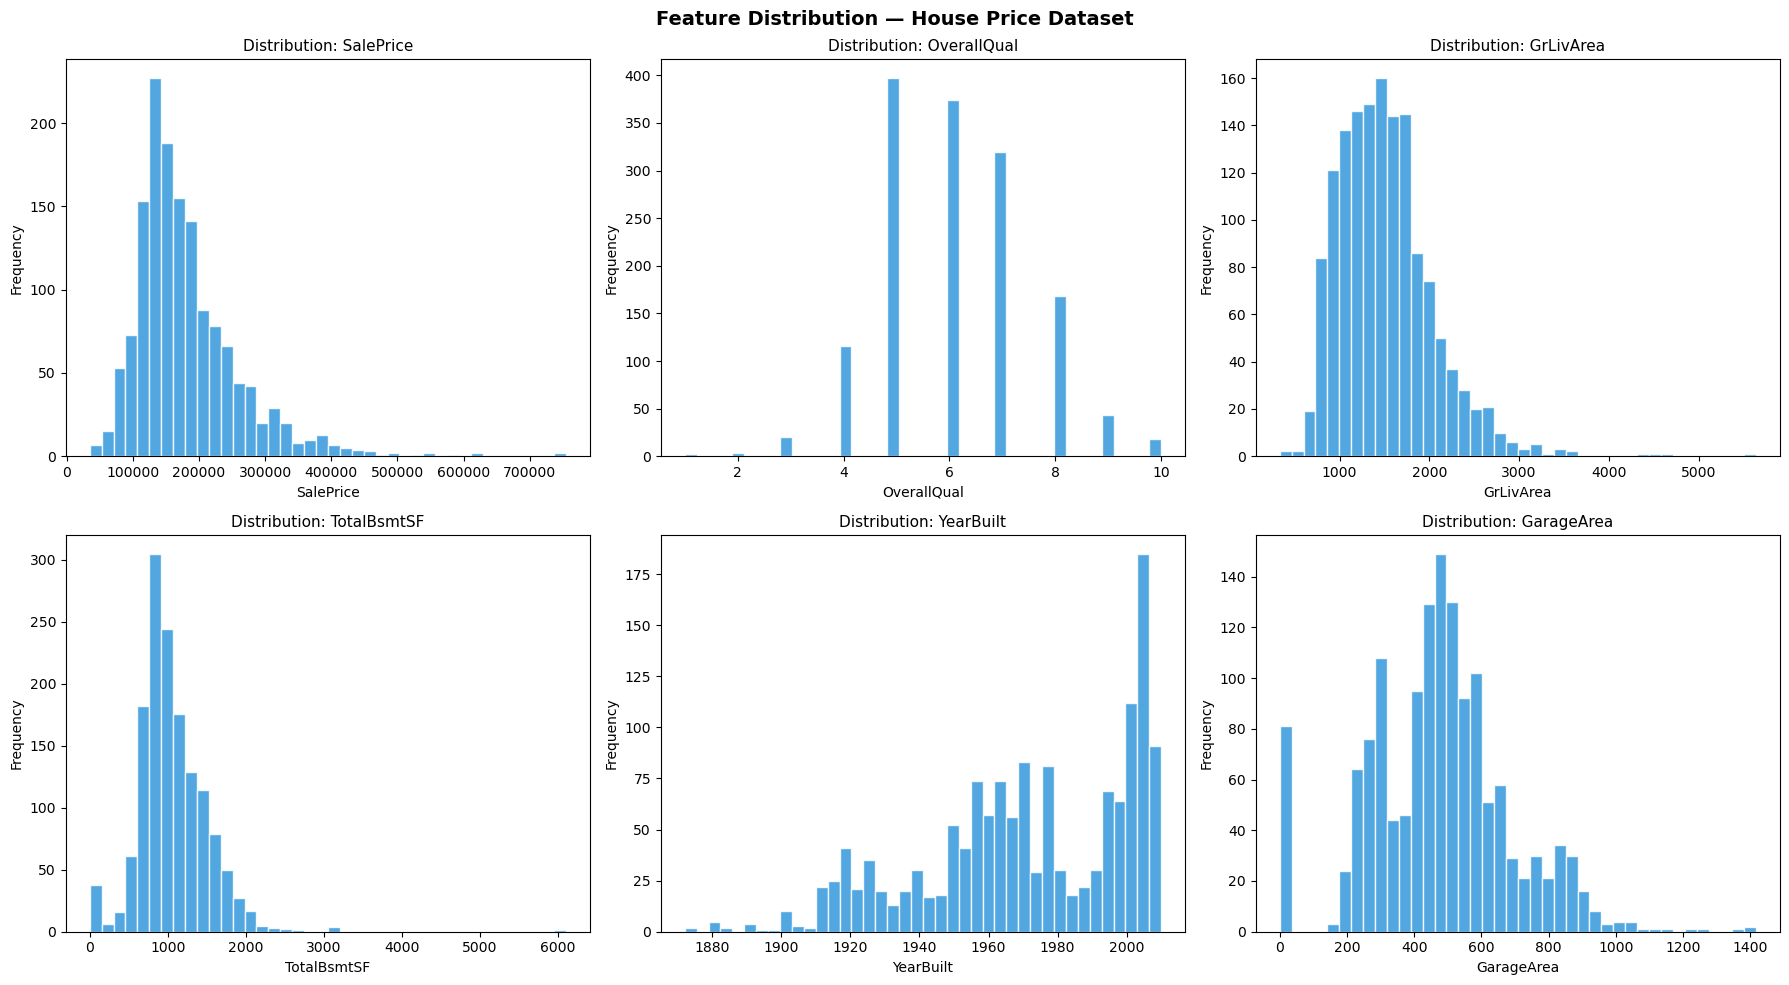

✅ Saved: /Users/mymac/anaconda_projects/portofolio/models/feature_distribution.png


In [17]:
top_feats = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'GarageArea']
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle("Feature Distribution — House Price Dataset", fontsize=14, fontweight='bold')

for ax, feat in zip(axes2.flatten(), top_feats):
    if feat in df.columns:
        ax.hist(df[feat].dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.85)
        ax.set_title(f"Distribution: {feat}", fontsize=11)
        ax.set_xlabel(feat)
        ax.set_ylabel("Frequency")

plt.tight_layout()
dist_path = os.path.join(MODELS_DIR, "feature_distribution.png")
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {dist_path}")

### 5c. Correlation Heatmap

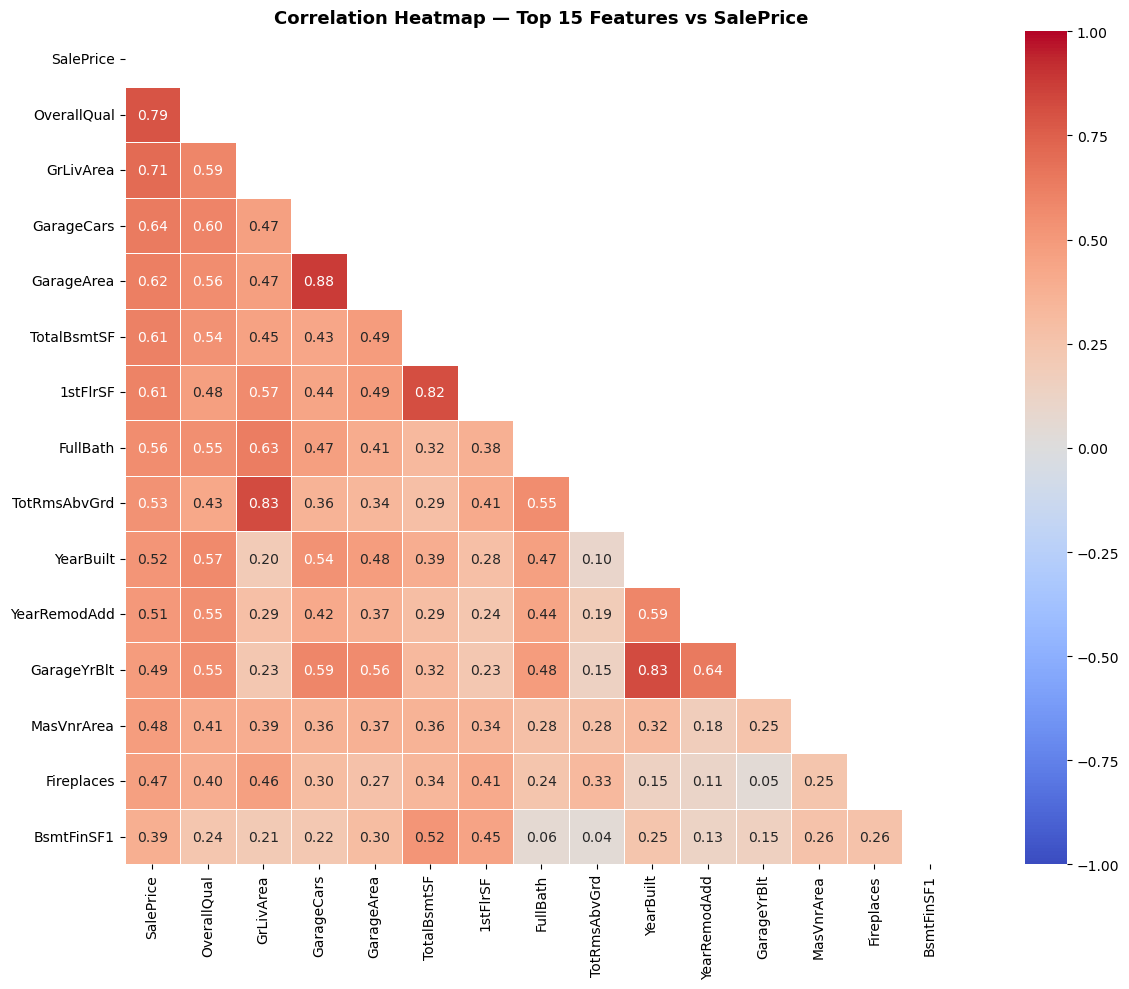

✅ Saved: /Users/mymac/anaconda_projects/portofolio/models/correlation_heatmap.png


In [18]:
num_df   = df[NUM_COLS + ['SalePrice']].copy()
top_corr = num_df.corr()['SalePrice'].abs().nlargest(15).index.tolist()
corr_mat = num_df[top_corr].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Top 15 Features vs SalePrice",
          fontsize=13, fontweight='bold')
plt.tight_layout()
heatmap_path = os.path.join(MODELS_DIR, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {heatmap_path}")

---
## 6️⃣ Simpan Model & Artifacts

In [19]:
# Simpan model
model_path = os.path.join(MODELS_DIR, "house_price_model.pkl")
joblib.dump(best_model, model_path)
print(f"✅ Model   : {model_path}")

# Simpan feature info
feat_info = {
    "num_cols"         : NUM_COLS,
    "cat_cols"         : CAT_COLS,
    "drop_cols"        : DROP_COLS,
    "all_feature_cols" : NUM_COLS + CAT_COLS,
}
feat_path = os.path.join(MODELS_DIR, "feature_info.json")
with open(feat_path, "w") as f:
    json.dump(feat_info, f, indent=2)
print(f"✅ Features: {feat_path}")

# Simpan metrics
metrics_path = os.path.join(MODELS_DIR, "model_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"✅ Metrics : {metrics_path}")

# Simpan cleaned data
clean_path = os.path.join(MODELS_DIR, "train_clean.csv")
df.to_csv(clean_path, index=False)
print(f"✅ Data    : {clean_path}")

✅ Model   : /Users/mymac/anaconda_projects/portofolio/models/house_price_model.pkl
✅ Features: /Users/mymac/anaconda_projects/portofolio/models/feature_info.json
✅ Metrics : /Users/mymac/anaconda_projects/portofolio/models/model_metrics.json
✅ Data    : /Users/mymac/anaconda_projects/portofolio/models/train_clean.csv


---
## ✅ Selesai!

Semua artifact tersimpan di folder `models/`:

| File | Deskripsi |
|------|-----------|
| `house_price_model.pkl` | Model Gradient Boosting yang sudah dilatih |
| `feature_info.json` | Daftar fitur numerik & kategorikal |
| `model_metrics.json` | Metrik evaluasi semua model |
| `train_clean.csv` | Dataset setelah preprocessing |
| `model_performance.png` | Visualisasi performa model |
| `feature_distribution.png` | Distribusi fitur utama |
| `correlation_heatmap.png` | Korelasi fitur terhadap SalePrice |

Untuk menjalankan aplikasi: `streamlit run app/app.py`